In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
import sys
sys.path.append("../code/libs")
sys.path.append('helpers')
from scipy.stats import pearsonr

In [3]:
%reload_ext autoreload
%autoreload 2

import census as cn
import annotations as ans
import geo
import viz
import twitter
import ios
import text
from constants import NONE

In [4]:
viz.sns_reset()
viz.sns_paper_style()

# Setup

In [5]:
CCODES3 = ['USA', 'CAN']
CCODES2 = ['US', 'CA']

FN_FULL_CORPUS = '../results/full_corpus_2M_merged_tweets_users.pkl'
FN_VALID_CORPUS = '../results/valid_corpus_305K_merged_tweets_users.pkl'
FN_FINAL_CORPUS = '../results/final_corpus_74K_merged_tweets_users_valid.pkl'

FN_DATA = f"../results/census_twitter_data/<CCODE3>_stats.csv" # file containing census & twitter data per region and year
FN_CENSUS = '../data/census/<CCODE3>/<CCODE3>_all_census_stats.csv'

ROOT_DIR = '../results/ICWSM/'
OUTPUT_DIR = ios.path_join(ROOT_DIR, 'plots/')
FN_ICWSM_CORPUS = ios.path_join(OUTPUT_DIR, 'agg_corpus_twitter_survey_data.pkl')
PVALUE = 0.05 
MAX_VAR = 1e-8
DPI = 300
RQ = 'RQ3'

# All Data

In [6]:
df_merged_valid = ios.read_pickle(FN_VALID_CORPUS) # tweets with metadata and user metadata worldwide
df_merged_valid.shape, df_merged_valid.tweet_id.nunique(), df_merged_valid.author_id.nunique()

((305524, 41), 305524, 240881)

In [7]:
df_merged_valid.head(5)

,tweet_id,author_id,corpus,score_q1,score_q2,score_q3,score_q4,score_q5,score_q6,score_q7,...,description,created_at_a,verified,cap,valid_user,loc_source,ccode_a,geometry_a,lon_a,lat_a
0,1417673516414013440,2766734643,@loftmusik_ never been pregnant but if i were ...,0.732504,0.67069,0.760165,0.581427,0.681276,0.444975,0.526308,...,20. capricorn. child advocate. nazi feminist. ...,2014-09-11 00:12:24,False,0.278726,True,tweets,US,POINT (-92.13000 34.75000),-92.13,34.75
1,1417602329235361797,2422554078,@maryxwetzel i (my pregnant self) smoke weed i...,0.433795,0.577831,0.390623,0.492191,0.396159,0.437249,0.239965,...,homebody 🍂,2014-04-01 19:16:20,False,0.000000,True,NaN,NaN,None,NaN,NaN
2,1416918506055081985,166379492,"@sbram94 since birth, too? i was a single-foot...",0.559071,0.550456,0.511389,0.504051,0.512161,0.312145,0.30415,...,RI➡️FL➡️GA. NE Patriots fan for LIFE; kicking ...,2010-07-14 00:49:06,False,0.306188,True,tweets,US,POINT (-68.98000 45.19000),-68.98,45.19
3,1416836524524539904,64567001,i don't understand woman expecting baby(s) the...,0.566753,0.646126,0.540336,0.534086,0.439238,0.288065,0.272889,...,"Mom of 3 ❤️ TATTOOS 🖋 I'm a rebel, Idgaf. 🇲🇽#G...",2009-08-11 00:25:21,False,0.391216,True,tweets,US,POINT (-111.93000 34.17000),-111.93,34.17
5,1414904849842548736,882480253217714180,@katstillhere nope.. i never smoked weed.. two...,0.525929,0.61277,0.500927,0.455691,0.409603,0.406275,0.365028,...,-Born/Raised in Hawaii. \n-Lived in Ca for 13 ...,2017-07-05 06:04:22,False,0.761188,True,NaN,NaN,None,NaN,NaN


# Fast Clustering

In [8]:
df_merged_valid_usa_can = df_merged_valid.query("ccode_a in ['US','CA']").copy()
df_merged_valid_usa_can.shape

(53184, 41)

In [9]:
model_, corpus_sentences_, corpus_embeddings_, clusters_with_sentences_ = text.fast_clustering(df=df_merged_valid_usa_can, 
                                                                                                column='corpus',
                                                                                                min_community_size=25,
                                                                                                threshold=0.75,
                                                                                                output_dir=ROOT_DIR,
                                                                                                prefix=RQ,
                                                                                                postfix='small')

loading...


In [10]:
text_cluster_map = {text:cluster_id+1 for cluster_id, cluster in enumerate(clusters_with_sentences_) for text in cluster}
df_merged_valid_usa_can.loc[:,'cluster_id'] = df_merged_valid_usa_can.corpus.apply(lambda text: text_cluster_map[text] if text in text_cluster_map else -1)
df_merged_valid_usa_can.head(2)


,tweet_id,author_id,corpus,score_q1,score_q2,score_q3,score_q4,score_q5,score_q6,score_q7,...,created_at_a,verified,cap,valid_user,loc_source,ccode_a,geometry_a,lon_a,lat_a,cluster_id
0,1417673516414013440,2766734643,@loftmusik_ never been pregnant but if i were ...,0.732504,0.67069,0.760165,0.581427,0.681276,0.444975,0.526308,...,2014-09-11 00:12:24,False,0.278726,True,tweets,US,POINT (-92.13000 34.75000),-92.13,34.75,-1
2,1416918506055081985,166379492,"@sbram94 since birth, too? i was a single-foot...",0.559071,0.550456,0.511389,0.504051,0.512161,0.312145,0.30415,...,2010-07-14 00:49:06,False,0.306188,True,tweets,US,POINT (-68.98000 45.19000),-68.98,45.19,-1


In [11]:
CLUSTER = -1

if CLUSTER == -1:
    print(df_merged_valid_usa_can.query('cluster_id==-1').corpus.sample(1).iloc[0])
else:
    for cluster_id, cluster in enumerate(clusters_with_sentences_):
        if cluster_id == CLUSTER-1:
            print(f"\nCluster {cluster_id+1}")
            for corpus in cn.np.random.choice(cluster, 10):
                print(corpus)


i smoke way to much weed to get any bitch pregnant


## Cluster metadata (both countries)
Manual labeling

In [12]:
CLUSTERS_OTHERS = [2, 4, 6, 8, 14, 15, 21, 24, 25, 26, 30, 32, 37, 40, 41, 50, 55, 58, 60, 66, 68, 73, 78, 79] # cluster_ids as others
CLUSTERS_MULTIPLE = [22, 49, 53, 35, 59, 63, 44]
MULTIPLE_SUMMARY_INDEXES = [5,6,7,8]
CLUSTERS_MULTIPLE_NAMES = ['Questions, Research', 'Questions, Research, Experiences', 'Criticism, Experiences', 'Experiences, Research']

In [13]:
df_clusters_metadata = text.load_clusters_metadata()
df_clusters_metadata.head(2)

,order,cluster,tweets,topic,subtopic,example
0,1,5,316,Research,Baby boomers and cannabis use,Marijuana use is increasing among American bab...
1,1,1,6802,Research,CanPreg studies,Marijuana use doubles the risk of premature bi...


In [14]:
df_clusters_metadata.tweets.sum()

14365

In [15]:
df_clusters_metadata.query("topic == 'Others'").example.iloc[0]

'Haven’t smoked weed in 6 months. That first one will hit hard! [URL]'

# Plots

In [16]:
viz.sns_reset()
viz.sns_paper_style()

## Basic

## Both countries

In [17]:
latex = df_clusters_metadata.query("cluster>=1").sort_values('tweets', ascending=False).drop(columns=['order']).reset_index(drop=True)
latex.loc[:,'topic'] = latex.topic.apply(lambda x: f"{x.lower()}")

K = 5

# Get the top K rows
top = latex.head(K)

# Get the middle K rows
middle_index = len(latex) // 2
minus = K // 2
plus = K // 2 + K % 2
middle = latex.iloc[middle_index - minus:middle_index + plus]  # Adjust for 0-based indexing

# Get the bottom rows
bottom = latex.tail(K)

# Combine the results into a single DataFrame
result = cn.pd.concat([top, middle, bottom])

with cn.pd.option_context('display.max_colwidth', None):
    result = result.to_latex(index=False, caption='Clusters by Number of Tweets', label='tbl:clusters')
print(result)


\begin{table}
\centering
\caption{Clusters by Number of Tweets}
\label{tbl:clusters}
\begin{tabular}{rrlll}
\toprule
 cluster &  tweets &                 topic &                              subtopic &                                                                        example \\
\midrule
       1 &    6802 &              research &                       CanPreg studies &         Marijuana use doubles the risk of premature birth. [URL] via [MENTION] \\
       3 &     532 &             criticism &       Criticism of CanPreg in general &          I don’t understand why pregnant women smoke weed or cigarettes smh 😔. \\
       5 &     316 &              research &         Baby boomers and cannabis use &                 Marijuana use is increasing among American baby boomers. [URL] \\
       7 &     213 &             questions &           CBD safety during pregnancy &                          Is using CBD to manage pregnancy symptoms safe? [URL] \\
       9 &     173 &                  n

In [18]:
with cn.pd.option_context('display.max_colwidth', None):
    latex = df_clusters_metadata.sort_values(['order','tweets'], ascending=[True,False])[['cluster','tweets','topic','subtopic','example']].to_latex(index=False, 
                                                                                                      caption='Clusters by Number of Tweets', 
                                                                                                      label='tbl:clusters')
print(latex)

\begin{table}
\centering
\caption{Clusters by Number of Tweets}
\label{tbl:clusters}
\begin{tabular}{rrlll}
\toprule
 cluster &  tweets &                            topic &                                subtopic &                                                                             example \\
\midrule
       1 &    6802 &                         Research &                         CanPreg studies &              Marijuana use doubles the risk of premature birth. [URL] via [MENTION] \\
       5 &     316 &                         Research &           Baby boomers and cannabis use &                      Marijuana use is increasing among American baby boomers. [URL] \\
      13 &     144 &                         Research &                Newborn cannabis testing &             Baby soaps and shampoos can cause false positive marijuana tests. [URL] \\
      28 &      64 &                         Research &                            Opiate abuse &           Preventing opiate-addicted

In [19]:
df_clusters_metadata.cluster.nunique(), len(CLUSTERS_OTHERS), df_clusters_metadata.cluster.nunique() + len(CLUSTERS_OTHERS)

(57, 24, 81)

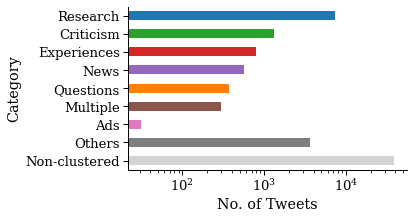

In [20]:
tmp = df_clusters_metadata.groupby(['order','topic']).tweets.sum().reset_index()
tmp = text.prepare_cluster_metadata_summary(tmp, MULTIPLE_SUMMARY_INDEXES)
tmp = cn.pd.concat([tmp, cn.pd.DataFrame({'order': [12], 
                                    'topic': ['Non-clustered'], 
                                    'tweets': [df_merged_valid_usa_can.shape[0]-tmp.tweets.sum()]})])

ax = tmp[::-1].plot(kind='barh', x='topic', y='tweets', 
                    legend=False, figsize=(5,3), 
                    logx=True,
                    color=['tab:blue','tab:green','tab:red','tab:purple','tab:orange', 'tab:brown', 'tab:pink','tab:grey', 'lightgrey'][::-1])
ax.set_xlabel('No. of Tweets')
ax.set_ylabel('Category')
ax.spines[['right', 'top']].set_visible(False)

fn = ios.path_join(OUTPUT_DIR, f'{RQ}_clusters_categories.pdf')
viz.plt.savefig(fn, bbox_inches='tight', dpi=viz.DPI)

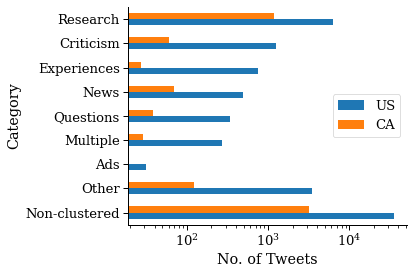

In [29]:
df_clusters_metadata_by_country = text.prepare_cluster_metadata_by_country(df_merged_valid_usa_can, df_clusters_metadata, CCODES2, MULTIPLE_SUMMARY_INDEXES)

ax = df_clusters_metadata_by_country.plot.barh(logx=True, figsize=(5,4), color=viz.CUSTTOME_PALETTE)
ax.set_xlabel('No. of Tweets')
ax.set_ylabel('Category')
ax.legend(loc='center right')
ax.spines[['right', 'top']].set_visible(False)

fn = ios.path_join(OUTPUT_DIR, f'{RQ}_clusters_categories_by_country.pdf')
viz.plt.savefig(fn, bbox_inches='tight', dpi=viz.DPI)

## Each country

In [53]:
cid = 0
ccode3 = CCODES3[cid]
ccode2 = CCODES2[cid]

data = df_merged_valid_usa_can.query("ccode_a==@ccode2").copy()

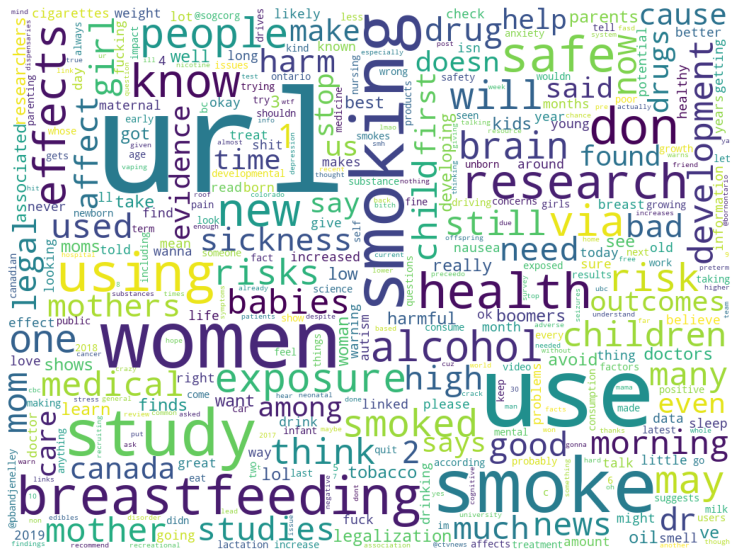

In [25]:
wc = text.get_wordcloud(data, 'corpus', remove_keywords=True)

fn = ios.path_join(OUTPUT_DIR, f'{RQ}_{ccode3}_worldcloud.pdf')
viz.plot_wordcloud(wc, figsize=(20,10), fn=fn)

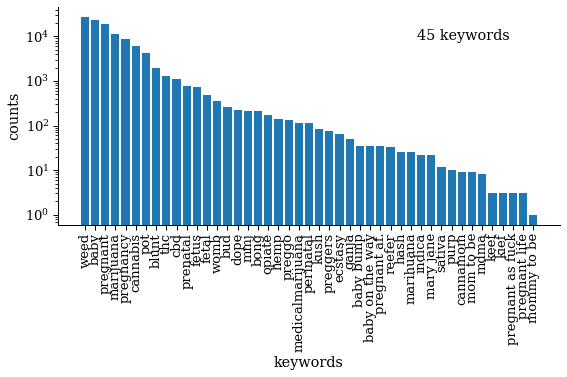

In [29]:
kcounts = text.get_keyword_counts(data, 'corpus')

fn = ios.path_join(OUTPUT_DIR, f'{RQ}_{ccode3}_keyworkds_count.pdf')
viz.plot_keyword_count(kcounts, logy=True, topk=None, fn=fn)

# BERTOPIC

In [9]:
df_merged_valid_usa_can = df_merged_valid.query("ccode_a in ['US','CA']").copy()
df_merged_valid_usa_can.shape

(53184, 41)

In [ ]:
df_merged_valid_usa_can.head(2)

,tweet_id,author_id,corpus,score_q1,score_q2,score_q3,score_q4,score_q5,score_q6,score_q7,...,description,created_at_a,verified,cap,valid_user,loc_source,ccode_a,geometry_a,lon_a,lat_a
0,1417673516414013440,2766734643,@loftmusik_ never been pregnant but if i were ...,0.732504,0.67069,0.760165,0.581427,0.681276,0.444975,0.526308,...,20. capricorn. child advocate. nazi feminist. ...,2014-09-11 00:12:24,False,0.278726,True,tweets,US,POINT (-92.13000 34.75000),-92.13,34.75
2,1416918506055081985,166379492,"@sbram94 since birth, too? i was a single-foot...",0.559071,0.550456,0.511389,0.504051,0.512161,0.312145,0.30415,...,RI➡️FL➡️GA. NE Patriots fan for LIFE; kicking ...,2010-07-14 00:49:06,False,0.306188,True,tweets,US,POINT (-68.98000 45.19000),-68.98,45.19


In [42]:
import numpy as np
import matplotlib.pyplot as plt
from bertopic import BERTopic
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import pickle

# Function to compute the elbow method for BERTopic
def find_optimal_clusters(docs, start_k=2, end_k=10):
    topic_model = BERTopic()
    embeddings = topic_model.fit_transform(docs)[1]  # Extract embeddings
    
    distortions = []
    silhouette_scores = []
    
    for k in range(start_k, end_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(embeddings.reshape(-1, 1))
        distortions.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(embeddings.reshape(-1, 1), kmeans.labels_))

    return distortions, silhouette_scores

# Function to save BERTopic model and results
def save_model_and_results(topic_model, file_name):
    with open(f"{file_name}", "wb") as f:
        pickle.dump(topic_model, f)

# Function to load BERTopic model and results
def load_model_and_results(file_name):
    with open(f"{file_name}", "rb") as f:
        return pickle.load(f)
    
    docs = [
        "I love programming in Python.",
        "Natural Language Processing is amazing.",
        "BERTopic is a useful topic modeling tool.",
        "Machine learning and AI are the future.",
        "Clustering helps in finding patterns in data.",
        "The elbow method is useful for finding the optimal number of clusters."
    ]

    # Find the optimal number of clusters
    distortions, silhouette_scores = find_optimal_clusters(docs, start_k=2, end_k=10)

    # Plot the elbow method and silhouette scores
    plt.figure(figsize=(12, 6))

    # Elbow Method
    plt.subplot(1, 2, 1)
    plt.plot(range(2, 11), distortions, marker='o')
    plt.title('Elbow Method')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Distortion')

    # Silhouette Scores
    plt.subplot(1, 2, 2)
    plt.plot(range(2, 11), silhouette_scores, marker='o', color='orange')
    plt.title('Silhouette Scores')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Score')

    plt.tight_layout()
    plt.show()

    # Train and save the best BERTopic model based on results
    optimal_k = int(input("Enter the optimal number of clusters based on the elbow method: "))
    final_model = BERTopic()
    topics, _ = final_model.fit_transform(docs)

    save_model_and_results(final_model, "bertopic_model")

    print("BERTopic model saved as 'bertopic_model.pkl'.")

    # Load the model and use it
    loaded_model = load_model_and_results("bertopic_model")
    print("Loaded BERTopic model:", loaded_model)

In [ ]:
# Sample documents
docs = df_merged_valid_usa_can.corpus.tolist()

KVALS = 15

# Find the optimal number of clusters
distortions, silhouette_scores = find_optimal_clusters(docs, start_k=2, end_k=KVALS)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

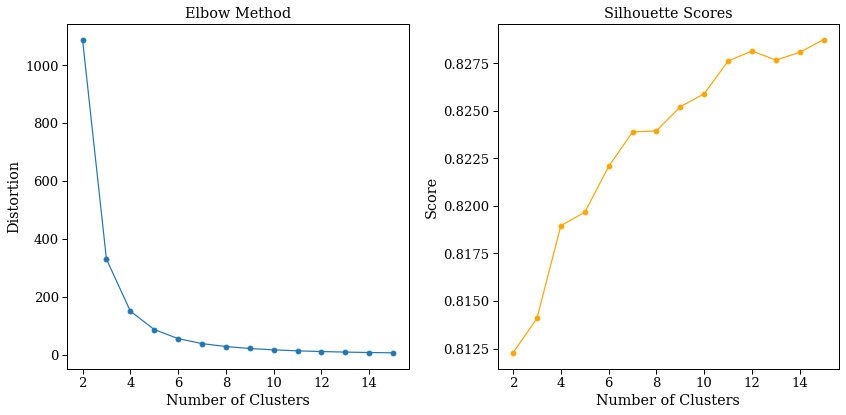

In [13]:
# Plot the elbow method and silhouette scores
plt.figure(figsize=(4, 8))

# Elbow Method
plt.subplot(2, 1, 1)
plt.plot(range(2, KVALS+1), distortions, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Distortion')

# Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(range(2, KVALS+1), silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters')
plt.ylabel('Score')

plt.tight_layout()
plt.show()

In [ ]:
from bertopic import BERTopic
from sklearn.cluster import KMeans
import numpy as np

optimal_k = 4
RESULTS_DIR = ios.path_join(ROOT_DIR, 'BERTopic')
fn = ios.path_join(RESULTS_DIR, f"bertopic_model_k{optimal_k}.pkl")
print(fn)

if ios.exists(fn):
    print('loading...')
    # Load the model and use it
    topic_model = load_model_and_results(fn)
    print("Loaded BERTopic model:", final_model)
else:
    
    # Train BERTopic and extract embeddings
    topic_model = BERTopic()
    topics, embeddings = topic_model.fit_transform(docs)

    # Use optimal_k to create exactly that many clusters
    kmeans = KMeans(n_clusters=optimal_k, random_state=42)
    labels = kmeans.fit_predict(embeddings.reshape(-1, 1))
    
    # Update BERTopic with the new topics from KMeans
    # This overrides the original topics created by BERTopic
    topic_model.custom_labels_ = labels

    # Inspect the new topic labels
    print(f"Assigned Topics: {np.unique(labels)}")
    save_model_and_results(topic_model, fn)

../results/ICWSM/BERTopic/bertopic_model_k4.pkl
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLE

In [64]:
topic_model.get_document_info(docs).Topic.nunique()

542

In [65]:
for topic in range(4):
    print(f"Topic {topic}: {topic_model.get_topic(topic)}")


Topic 0: [('she', 0.016978015210483775), ('her', 0.013826791451815226), ('left', 0.011551332723707317), ('excuse', 0.01020880263860481), ('lady', 0.0075225570290449436), ('home', 0.007005445403645325), ('bitch', 0.006494837072135679), ('said', 0.005809381073045913), ('shes', 0.004713131571839332), ('baby', 0.0044783701871683014)]
Topic 1: [('blunt', 0.05106867386729848), ('wanna', 0.010989007096757044), ('fat', 0.010488066183460735), ('bed', 0.009953557361092694), ('sleep', 0.009634953267491973), ('my', 0.008060951573430846), ('with', 0.007647915781189931), ('wait', 0.007551077011701932), ('lay', 0.007268365121768745), ('smoke', 0.007134265905156238)]
Topic 2: [('sleep', 0.05501795618265957), ('sleeping', 0.022154809135160165), ('slept', 0.019854488748957573), ('night', 0.01824713963023476), ('like', 0.01620798461415081), ('bed', 0.013186245254310685), ('asleep', 0.010813853656727266), ('sleepy', 0.007690088200763828), ('makes', 0.007547777634278092), ('wake', 0.0073968098588114255)]
T

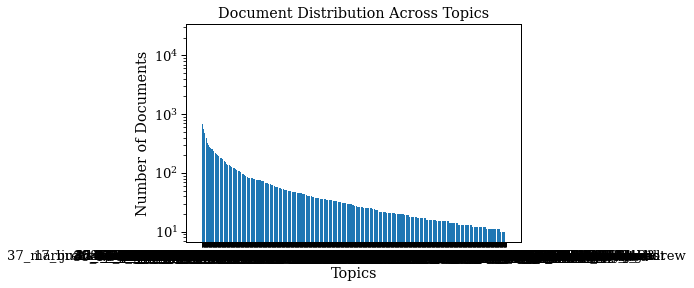

In [66]:
import matplotlib.pyplot as plt

topic_counts = topic_model.get_topic_info()["Count"]
topics = topic_model.get_topic_info()["Name"]

plt.bar(topics, topic_counts)
plt.xlabel("Topics")
plt.ylabel("Number of Documents")
plt.title("Document Distribution Across Topics")
plt.yscale("log")
plt.show()

In [72]:
topic_model.visualize_barchart(top_n_topics=4)


In [74]:
for topic in range(4):
    example_docs = topic_model.get_representative_docs(topic)
    print(f"Topic {topic} Example Documents: {example_docs}")


Topic 0 Example Documents: ["she like i left my weed at home can you give me some, baby girl that's not a excuse", 'she like she left her weed at home.. baby that is not a excuse.', 'she said she left her weed at home,...baby that is not an excuse.']
Topic 1 Example Documents: ['smoking a blunt with my baby<3', 'smoking a blunt with my baby 😚💨', 'smoking a blunt with my baby. <3']
Topic 2 Example Documents: ['you sleep like you pregnant no i sleep like i smoke weed to much.', 'weed = sleep like baby', 'smoke more weed i sleep like a baby']
Topic 3 Example Documents: ['@ndabaz_m @smoke_nd_pearlz you can smoke weed while pregnant 😂', "'@og_mimi smoking weed while pregnant <<<'", 'shit idk about all that rt @lifeeofah_bosss its not bad to smoke weed during pregnancy, its weed!']


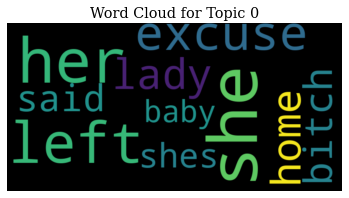

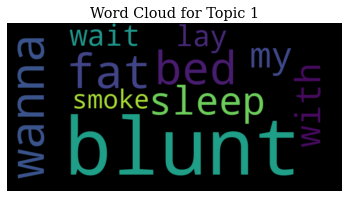

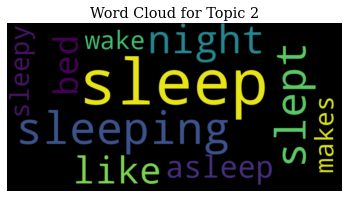

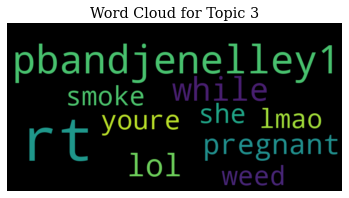

In [75]:
from wordcloud import WordCloud

for topic in range(4):
    words = dict(topic_model.get_topic(topic))
    wordcloud = WordCloud(width=800, height=400).generate_from_frequencies(words)
    plt.figure()
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.title(f"Word Cloud for Topic {topic}")
    plt.axis("off")
    plt.show()
